In [ ]:
pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.4/491.4 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 9.3 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2025.3.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is in

In [ ]:
import tensorflow as tf
from tensorflow.keras.callbacks import TensorBoard
from keras.utils import to_categorical
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers.schedules import PolynomialDecay
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from datasets import load_dataset
from transformers import TFDistilBertForSequenceClassification, DistilBertTokenizer, DataCollatorWithPadding
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

In [ ]:
amazon_train = load_dataset('amazon_polarity', split='train[:10000]')
amazon_test = load_dataset('amazon_polarity', split='test[:1000]')

README.md:   0%|          | 0.00/6.81k [00:00<?, ?B/s]

train-00000-of-00004.parquet:   0%|          | 0.00/260M [00:00<?, ?B/s]

train-00001-of-00004.parquet:   0%|          | 0.00/258M [00:00<?, ?B/s]

train-00002-of-00004.parquet:   0%|          | 0.00/255M [00:00<?, ?B/s]

train-00003-of-00004.parquet:   0%|          | 0.00/254M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/117M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3600000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/400000 [00:00<?, ? examples/s]

In [ ]:
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
def preprocess_text(text):
    text = text.lower()
    text = re.sub('[^0-9a-zA-Z]', ' ', text)
    words = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    words = [word for word in words if word not in stop_words]
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(word) for word in words]
    text = ' '.join(words)
    return text

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
df = pd.DataFrame({'Text': amazon_train['content'], 'Label': amazon_train['label']})
df['Text'] = df['Text'].apply(preprocess_text)
texts = df['Text'].tolist()
labels = df['Label'].tolist()

In [ ]:
df.head()

,Text,Label
0,sound track beautiful paint senery mind well w...,1
1,reading lot review saying best game soundtrack...,1
2,soundtrack favorite music time hand intense sa...,1
3,truly like soundtrack enjoy video game music p...,1
4,played game know divine music every single son...,1


In [ ]:

vocab_size = 25500
max_length = 100
trunc_type = 'post'
padding_type = 'post'
oov_token = ''
embedding_dim = 25
training_sentences = [preprocess_text(sentence) for sentence in amazon_train['content']]
testing_sentences = [preprocess_text(sentence) for sentence in amazon_test['content']]
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_token)
tokenizer.fit_on_texts(training_sentences)
train_sequences = tokenizer.texts_to_sequences(training_sentences)
test_sequences = tokenizer.texts_to_sequences(testing_sentences)
train_padded = pad_sequences(train_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)
test_padded = pad_sequences(test_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)
train_labels = amazon_train['label']
test_labels = amazon_test['label']
train_padded, test_padded = np.array(train_padded), np.array(test_padded)
train_labels, test_labels = np.array(train_labels), np.array(test_labels)

In [ ]:

embeddings_index = dict()
f = open('/content/glove.twitter.27B.25d.txt')
for line in f:
    values = line.split()
    word = values[0]
    coefs = np.asarray(values[1:], dtype='float32')
    embeddings_index[word] = coefs
f.close()
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, index in tokenizer.word_index.items():
    if index > vocab_size - 1:
        break
    else:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[index] = embedding_vector


In [ ]:
batch_size = 64
num_epochs = 3
num_train_steps = len(train_padded) // batch_size * num_epochs
lr_scheduler = PolynomialDecay(
    initial_learning_rate=1e-8, end_learning_rate=1e-3, decay_steps=num_train_steps
)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_scheduler)

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, embedding_dim,
        weights=[embedding_matrix], trainable=False),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(150, return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(150)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(loss=tf.keras.losses.BinaryCrossentropy(),
            optimizer=optimizer,
            metrics=['accuracy']
)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('lstm_model.h5', monitor='val_loss', save_best_only=True)
tensorboard_callback = TensorBoard(log_dir='./logs', histogram_freq=1)
# Train the model
history = model.fit(
    train_padded,
    train_labels,
    validation_data=(test_padded, test_labels),
    epochs=20,
    callbacks=[early_stopping, model_checkpoint, tensorboard_callback])

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5690 - loss: 0.6813

313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.5691 - loss: 0.6812 - val_accuracy: 0.6830 - val_loss: 0.6034
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6901 - loss: 0.5923

313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 30ms/step - accuracy: 0.6902 - loss: 0.5923 - val_accuracy: 0.6890 - val_loss: 0.5906
Epoch 3/20
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6969 - loss: 0.5769

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.6970 - loss: 0.5769 - val_accuracy: 0.7010 - val_loss: 0.5632
Epoch 4/20
311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7133 - loss: 0.5589

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.7133 - loss: 0.5588 - val_accuracy: 0.7020 - val_loss: 0.5626
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7290 - loss: 0.5472

...

313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.7609 - loss: 0.4950 - val_accuracy: 0.7430 - val_loss: 0.5095
Epoch 9/20
311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7739 - loss: 0.4760

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.7739 - loss: 0.4761 - val_accuracy: 0.7680 - val_loss: 0.5000
Epoch 10/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.7867 - loss: 0.4632 - val_accuracy: 0.7610 - val_loss: 0.5420
Epoch 11/20
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7860 - loss: 0.4640

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.7860 - loss: 0.4639 - val_accuracy: 0.7640 - val_loss: 0.4895
Epoch 12/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8023 - loss: 0.4359

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.8023 - loss: 0.4359 - val_accuracy: 0.7720 - val_loss: 0.4729
Epoch 13/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.8112 - loss: 0.4167 - val_accuracy: 0.7640 - val_loss: 0.4979
Epoch 14/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.8248 - loss: 0.4033 - val_accuracy: 0.7700 - val_loss: 0.4755
Epoch 15/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8327 - loss: 0.3770

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.8327 - loss: 0.3770 - val_accuracy: 0.7880 - val_loss: 0.4709
Epoch 16/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.8469 - loss: 0.3467 - val_accuracy: 0.7780 - val_loss: 0.5170
Epoch 17/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.8181 - loss: 0.4135 - val_accuracy: 0.7650 - val_loss: 0.5040
Epoch 18/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.8493 - loss: 0.3547 - val_accuracy: 0.7670 - val_loss: 0.4912
Epoch 19/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.8718 - loss: 0.3066 - val_accuracy: 0.7800 - val_loss: 0.5128
Epoch 20/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.8962 - loss: 0.2540 - val_accuracy: 0.7700 - val_loss: 0.5300


In [ ]:
best_model = tf.keras.models.load_model('lstm_model.h5')
test_loss, test_accuracy = best_model.evaluate(test_padded, test_labels)
print(f'Test Accuracy: {test_accuracy*100}%')

32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 263ms/step - accuracy: 0.7872 - loss: 0.4525
Test Accuracy: 78.79999876022339%


In [ ]:
from sklearn.metrics import classification_report
y_probs = best_model.predict(test_padded)
y_preds = (y_probs > 0.5).astype("int32").flatten()
print("\nClassification Report:")
print(classification_report(test_labels, y_preds, target_names=["Negative", "Positive"]))


32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 316ms/step

Classification Report:
              precision    recall  f1-score   support

    Negative       0.76      0.85      0.80       498
    Positive       0.83      0.73      0.78       502

    accuracy                           0.79      1000
   macro avg       0.79      0.79      0.79      1000
weighted avg       0.79      0.79      0.79      1000



32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


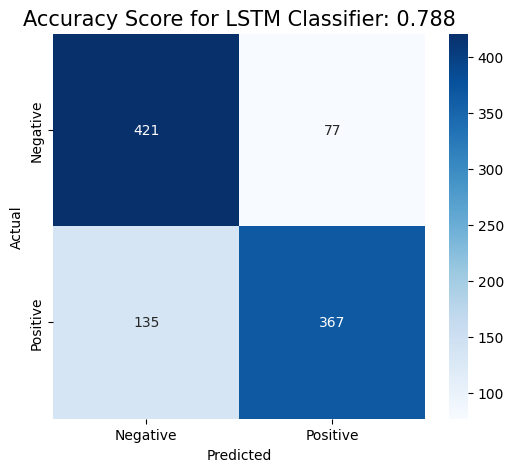

In [ ]:
from sklearn.metrics import confusion_matrix
predictions = best_model.predict(test_padded)
predicted_labels = (predictions >= 0.5).astype(int)
cf = confusion_matrix(test_labels, predicted_labels)
label_name=["Negative","Positive"]
plt.figure(figsize=(6,5))
sns.heatmap(cf,annot=True,fmt="d",cmap="Blues",xticklabels=label_name,yticklabels=label_name)
all_sample_title = f'Accuracy Score for LSTM Classifier: {test_accuracy:.4}'
plt.title(all_sample_title, size = 15)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

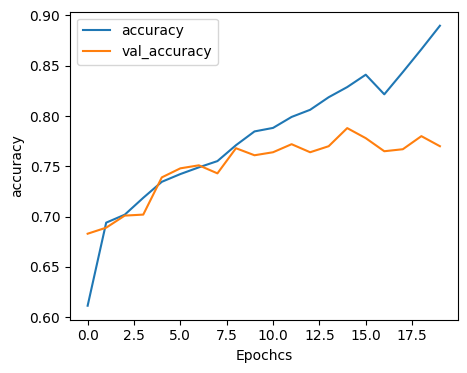

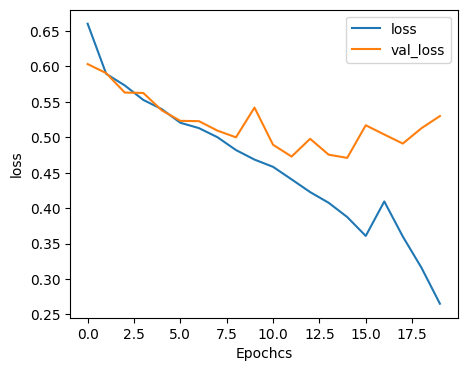

In [ ]:

def plot_graphs(history, string):
	plt.figure(figsize=(5,4))
	plt.plot(history.history[string])
	plt.plot(history.history['val_' + string])
	plt.xlabel("Epochcs")
	plt.ylabel(string)
	plt.legend([string, 'val_' + string])
	plt.show()
plot_graphs(history, "accuracy")
plot_graphs(history, "loss")

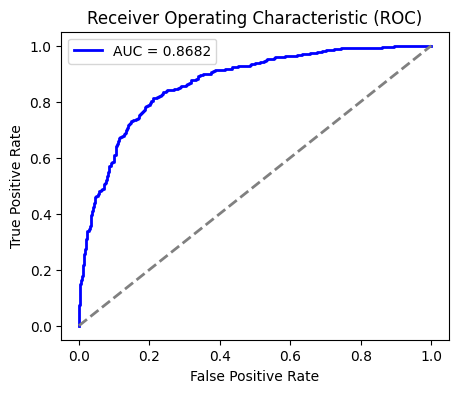

In [ ]:
from sklearn.metrics import roc_curve, auc
predictions_ravel = predictions.ravel()
fpr, tpr, thresholds = roc_curve(test_labels, predictions_ravel)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, color='blue', lw=2, label='AUC = {:.4f}'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend()
plt.show()

In [ ]:
def predict_sentiment(input_text):
    inputs = tokenizer.texts_to_sequences([input_text])
    padded = pad_sequences(inputs, maxlen=max_length,
                    padding=padding_type, truncating=trunc_type)
    preiction = model.predict(padded)
    predicted_class = (preiction >= 0.5).astype(int)
    sentiment_label = "positive" if predicted_class == 1 else "negative"
    return sentiment_label

In [ ]:
predicted_labels = (predictions >= 0.5).astype(int)
positive_sentences = [amazon_test['content'][i] for i, pred in enumerate(predicted_labels) if pred == 1]
negative_sentences = [amazon_test['content'][i] for i, pred in enumerate(predicted_labels) if pred == 0]
print("Positive Sentences:")
for i in range(2):
    print(positive_sentences[i])
    print("\n")

print("Negative Sentences:")
for i in range(2):
    print(negative_sentences[i])
    print("\n")

Positive Sentences:
My lovely Pat has one of the GREAT voices of her generation. I have listened to this CD for YEARS and I still LOVE IT. When I'm in a good mood it makes me feel better. A bad mood just evaporates like sugar in the rain. This CD just oozes LIFE. Vocals are jusat STUUNNING and lyrics just kill. One of life's hidden gems. This is a desert isle CD in my book. Why she never made it big is just beyond me. Everytime I play this, no matter black, white, young, old, male, female EVERYBODY says one thing "Who was that singing ?"


Despite the fact that I have only played a small portion of the game, the music I heard (plus the connection to Chrono Trigger which was great as well) led me to purchase the soundtrack, and it remains one of my favorite albums. There is an incredible mix of fun, epic, and emotional songs. Those sad and beautiful tracks I especially like, as there's not too many of those kinds of songs in my other video game soundtracks. I must admit that one of the 

In [ ]:
input_text = "Love this products. extremely good condition"
predicted_sentiment = predict_sentiment(input_text)
print(f"The sentiment is {predicted_sentiment}")
input_text = "Not working no matter how many time I changed the battery"
predicted_sentiment = predict_sentiment(input_text)
print(f"The sentiment is {predicted_sentiment}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
The sentiment is positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
The sentiment is negative
